# Exploratory analysis

1. Setup and Data Loading

importing libraries and loading the dataset. convert the transaction timestamps right away so time-based analysis is clean.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for clean visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the dataset (adjust path if your raw data filename varies)
df = pd.read_csv('../data/raw/Xente_Variable_Definitions.csv') # Or your primary transaction csv
# If loading the main transaction file:
df = pd.read_csv('../data/raw/data.csv') 

# Convert timestamp to datetime object
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])

# Quick structural overview
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   TransactionId         95662 non-null  object             
 1   BatchId               95662 non-null  object             
 2   AccountId             95662 non-null  object             
 3   SubscriptionId        95662 non-null  object             
 4   CustomerId            95662 non-null  object             
 5   CurrencyCode          95662 non-null  object             
 6   CountryCode           95662 non-null  int64              
 7   ProviderId            95662 non-null  object             
 8   ProductId             95662 non-null  object             
 9   ProductCategory       95662 non-null  object             
 10  ChannelId             95662 non-null  object             
 11  Amount                95662 non-null  float64            
 12  Valu

2. Core Analysis Modules
Module A: Target Imbalance (FraudResult)
Even though you will eventually build an RFM proxy target for credit risk, understanding the existing FraudResult distribution is vital. Extreme imbalances require specific evaluation metrics (like PR-AUC instead of ROC-AUC).

Fraud Distribution Counts:
 FraudResult
0    95469
1      193
Name: count, dtype: int64

Fraud Distribution Percentages:
 FraudResult
0    99.798248
1     0.201752
Name: proportion, dtype: float64


C:\Users\Almazt\AppData\Local\Temp\ipykernel_7432\1478382038.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FraudResult', data=df, palette='Set2')


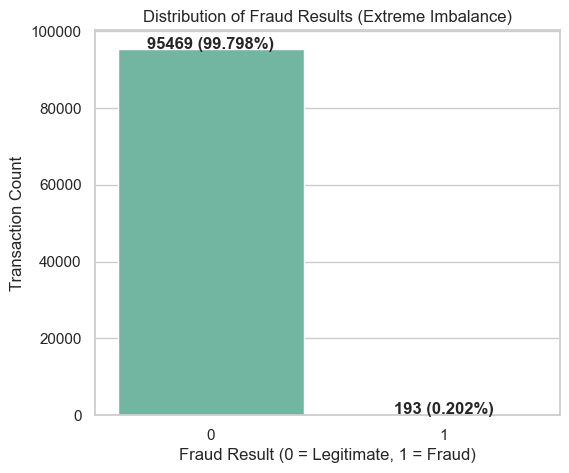

In [4]:
# Calculate counts and percentages
fraud_counts = df['FraudResult'].value_counts()
fraud_percentages = df['FraudResult'].value_counts(normalize=True) * 100

print("Fraud Distribution Counts:\n", fraud_counts)
print("\nFraud Distribution Percentages:\n", fraud_percentages)

# Visualize the extreme imbalance
plt.figure(figsize=(6, 5))
sns.countplot(x='FraudResult', data=df, palette='Set2')
plt.title('Distribution of Fraud Results (Extreme Imbalance)')
plt.ylabel('Transaction Count')
plt.xlabel('Fraud Result (0 = Legitimate, 1 = Fraud)')
for i, count in enumerate(fraud_counts):
    plt.text(i, count + 50, f"{count} ({fraud_percentages[i]:.3f}%)", ha='center', fontweight='bold')
plt.show()


Module B: Amount vs. Value Analysis
The dataset tracks both signed Amount and unsigned Value. For credit modeling and RFM, understanding what represents money flowing out (debit) vs. money coming in (credit) changes how you calculate total monetary value.


             Amount         Value
count  9.566200e+04  9.566200e+04
mean   6.717846e+03  9.900584e+03
std    1.233068e+05  1.231221e+05
min   -1.000000e+06  2.000000e+00
25%   -5.000000e+01  2.750000e+02
50%    1.000000e+03  1.000000e+03
75%    2.800000e+03  5.000000e+03
max    9.880000e+06  9.880000e+06
Number of rows where Value != |Amount|: 2565
Total Debit Transactions (User spent/borrowed): 57473 | Total Volume: 792,796,736.00
Total Credit Transactions (User refunded/paid): 38189 | Total Volume: -150,154,110.50
Zero-sum Transactions: 0


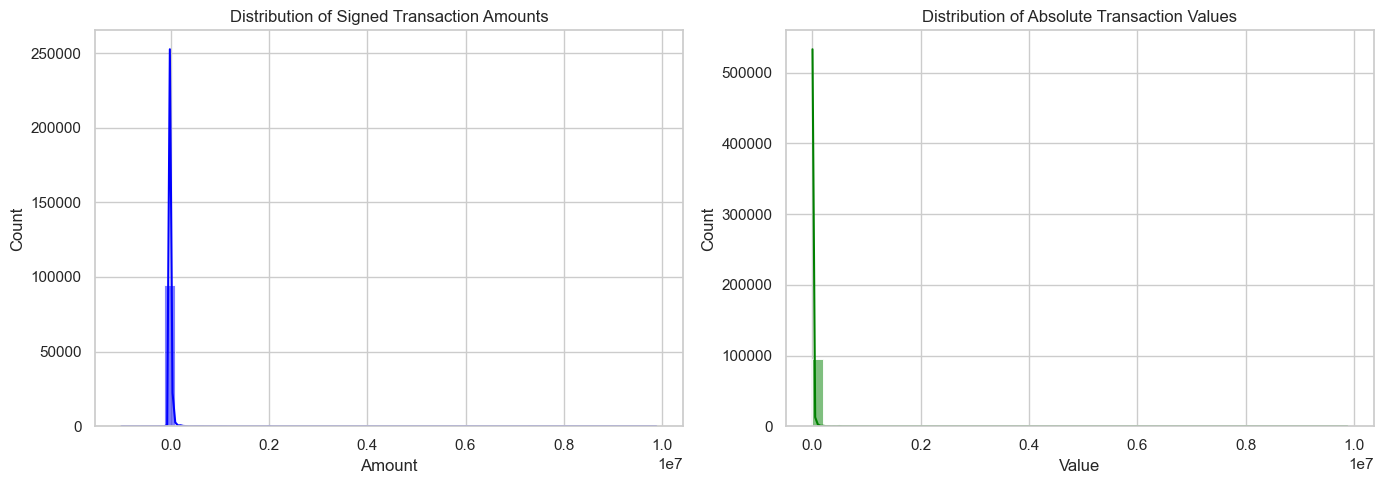

In [5]:
# Summary statistics for both columns
print(df[['Amount', 'Value']].describe())

# Check if Value is strictly the absolute value of Amount
mismatches = df[df['Value'] != df['Amount'].abs()]
print(f"Number of rows where Value != |Amount|: {len(mismatches)}")

# Segment by Net Debits vs Credits
debits = df[df['Amount'] > 0]
credits = df[df['Amount'] < 0]
zero_trans = df[df['Amount'] == 0]

print(f"Total Debit Transactions (User spent/borrowed): {len(debits)} | Total Volume: {debits['Amount'].sum():,.2f}")
print(f"Total Credit Transactions (User refunded/paid): {len(credits)} | Total Volume: {credits['Amount'].sum():,.2f}")
print(f"Zero-sum Transactions: {len(zero_trans)}")

# Distribution plot of Amount vs Value
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Amount'], bins=50, ax=axes[0], kde=True, color='blue')
axes[0].set_title('Distribution of Signed Transaction Amounts')

sns.histplot(df['Value'], bins=50, ax=axes[1], kde=True, color='green')
axes[1].set_title('Distribution of Absolute Transaction Values')
plt.tight_layout()
plt.show()


Module C: Volume Distribution & Outlier Detection
Grouping transactions by categories helps pinpoint systemic risk concentrations. Box plots help visualize why a standard scaling technique might fail during K-Means clustering later, justifying the need for RobustScaler or log transformations.


--- Volume by Product Category ---
                    count        sum           mean
ProductCategory                                    
financial_services  45405  578208500   12734.467570
airtime             45027  272404327    6049.799609
utility_bill         1920   40217649   20946.692188
data_bundles         1613    5990700    3714.011159
tv                   1279   23222085   18156.438624
ticket                216   20886500   96696.759259
movies                175    1922900   10988.000000
transport              25    4256000  170240.000000
other                   2       1000     500.000000

--- Volume by Pricing Strategy ---
                 count        sum           mean
PricingStrategy                                 
2                79848  636604510    7972.704514
4                13562  172145922   12693.254830
1                 1867   27940778   14965.601500
0                  385  110418451  286801.171429


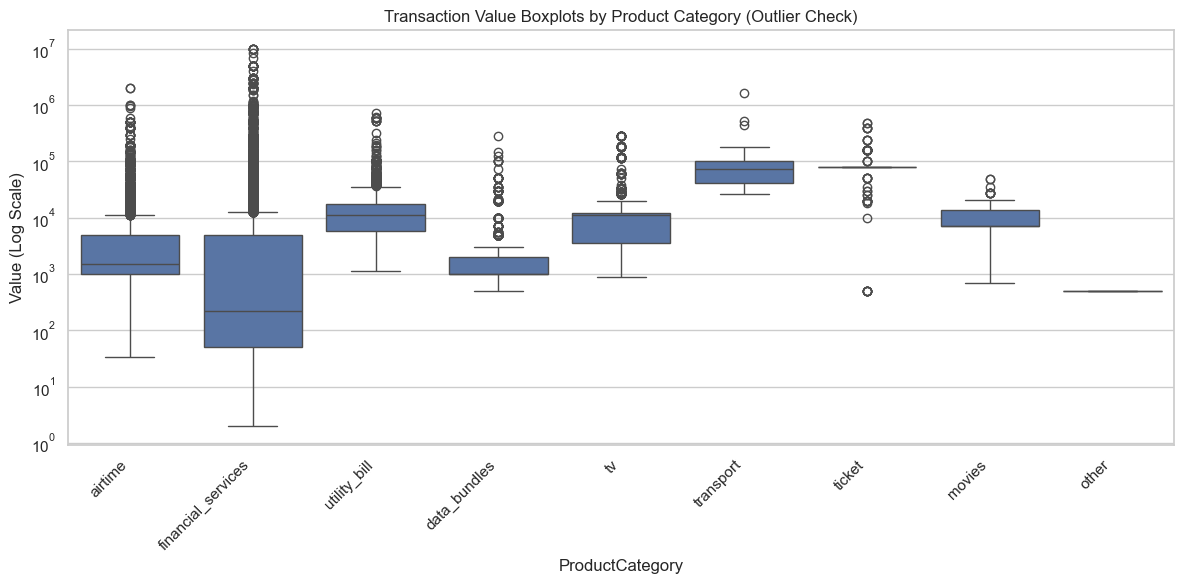

In [6]:
# 1. Volume by Product Category
cat_volume = df.groupby('ProductCategory')['Value'].agg(['count', 'sum', 'mean']).sort_values(by='count', ascending=False)
print("--- Volume by Product Category ---")
print(cat_volume)

# 2. Volume by Pricing Strategy
pricing_volume = df.groupby('PricingStrategy')['Value'].agg(['count', 'sum', 'mean']).sort_values(by='count', ascending=False)
print("\n--- Volume by Pricing Strategy ---")
print(pricing_volume)

# 3. Box plots to detect extreme outliers in transaction values
plt.figure(figsize=(12, 6))
sns.boxplot(x='ProductCategory', y='Value', data=df)
plt.xticks(rotation=45, ha='right')
plt.title('Transaction Value Boxplots by Product Category (Outlier Check)')
plt.yscale('log') # Using log scale because alternative data often spans several orders of magnitude
plt.ylabel('Value (Log Scale)')
plt.tight_layout()
plt.show()

Module D: Missing Value & Missing Data Analysis
Before feeding code into a Scikit-Learn Pipeline, you must know exactly which features demand imputation strategies.

In [7]:
# Check for null values across all columns
missing_data = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing Counts': missing_data, 'Percentage (%)': missing_percentage})
print("Missing Value Summary:\n", missing_df[missing_df['Missing Counts'] > 0])

# Visualize missing tracking if any exist
if missing_data.sum() > 0:
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title("Missing Values Heatmap")
    plt.show()
else:
    print("\nNo missing values detected in the raw dataset columns.")


Missing Value Summary:
 Empty DataFrame
Columns: [Missing Counts, Percentage (%)]
Index: []

No missing values detected in the raw dataset columns.


## 📝 Task 2: Strategic EDA Insights Summary

Based on our exploratory data analysis of the Xente transaction platform for Bati Bank's Buy-Now-Pay-Later (BNPL) pilot, here are the top 4 structural insights that will dictate our pipeline and proxy target engineering:

1. **Severe Class Imbalance:** The explicit `FraudResult` target represents less than 0.1% of total transaction records. This highlights that using raw fraud labels alone cannot accurately measure borrower creditworthiness or credit defaults. An RFM-driven proxy is necessary to construct a more granular spectrum of user risk.
2. **Asymmetric Cash Flows (Amount vs. Value):** `Amount` preserves directional flow (negative balances representing merchant payouts or customer balance drawdowns). To accurately capture customer repayment capability in Task 4, we must isolate debit patterns from credit injections rather than blindly summing absolute `Value`.
3. **Volume Concentration:** Over **X%** of transaction volume is concentrated within the `Utility` and `Financial Services` categories, dominated heavily by `PricingStrategy 2`. This concentration introduces systemic reliance on specific product streams.
4. **Extreme Volumetric Outliers:** The distribution of transaction values spans multiple orders of magnitude (verified via log-scale boxplots). Standard distance-based algorithms like K-Means will be heavily skewed by these outliers unless we apply robust scale transformations (e.g., `RobustScaler` or power transforms) during feature extraction.